# Notebook 5: The Full Pipeline — Training GeoTransolver on the Ahmed Body

---

## Where we are in the series

| Notebook | Topic |
|---|---|
| NB1 | Why standard Transformers fail at large meshes ($O(N^2)$) |
| NB2 | How Transolver fixes it: Physics-Attention ($O(N)$) |
| NB3 | Training Transolver on the Ahmed Body |
| NB4 | How GeoTransolver extends Transolver with GALE geometry injection |
| **NB5** | **Training GeoTransolver — same pipeline, same data, richer model** |

### What is the same as Notebook 3?
- **Zarr dataset** — identical files, no re-preprocessing.
- **Data pipeline** — `CAEDataset` + `TransolverDataPipe` (same classes, different config).
- **Normalization file** — same `surface_fields_normalization.npz`.
- **Training loop structure** — same epoch/val/checkpoint pattern.

### What is different?
- **Model** — `GeoTransolver` instead of `Transolver` (GALE cross-attention at every layer).
- **`broadcast_global_features=False`** — global flow conditions passed as a separate
  `global_embedding` rather than broadcast to every point.
- **`include_geometry=True`** — datapipe also returns `batch["geometry"]` (STL coordinates)
  for GALE cross-attention.
- **Forward call** — `model(global_embedding=..., local_embedding=..., geometry=..., local_positions=...)`

---
## 1. Imports

The imports are nearly identical to Notebook 3. The two key changes are:

1. **`GeoTransolver`** instead of `Transolver` — lives in the experimental namespace:  
   `physicsnemo.experimental.models.geotransolver.GeoTransolver`

2. **Same `TransolverDataPipe` / `CAEDataset`** — the pipeline classes are reused unchanged.  
   The difference is the *configuration* passed to `TransolverDataPipe`, not the class itself.

### `broadcast_global_features` — the critical switch

This one flag is what separates the Transolver and GeoTransolver data pipelines:

```
Transolver  (NB3):  broadcast_global_features = True
  Why: Transolver has no separate global-conditioning pathway.
       The only way flow conditions reach the model is if they are
       copied into every mesh point's feature vector.
       batch["fx"].shape = (1, N, 2)  ← 2 scalars × N points

GeoTransolver (NB5): broadcast_global_features = False
  Why: GALE re-injects geometry context at *every* transformer layer.
       Global flow conditions are passed as a dedicated global_embedding
       argument — separate from the per-point local geometry.
       batch["fx"].shape = (1, 1, 2)  ← 2 scalars, NOT repeated per-point
```

### Model selection via YAML config

In the production `transformer_models/src` workflow, Hydra selects the model class via:

```yaml
# conf/model/transolver.yaml
_target_: physicsnemo.models.transolver.Transolver
functional_dim: 2      ← fx:  air_density + stream_velocity (broadcast)
embedding_dim:  6      ← embedding: coords(3) + normals(3)
out_dim:        4

# conf/model/geotransolver.yaml
_target_: physicsnemo.experimental.models.geotransolver.GeoTransolver
functional_dim: 6      ← local_embedding:  coords(3) + normals(3)
global_dim:     2      ← global_embedding: air_density + stream_velocity
geometry_dim:   3      ← geometry:         STL coordinates (for GALE)
out_dim:        4
```

Notice how the **same data fields** map to **different model arguments**:
- In Transolver, `air_density + velocity` are part of `fx` (broadcast to N points).
- In GeoTransolver, `coords + normals` are the local functional input `local_embedding`,
  and `air_density + velocity` are passed as a *separate* `global_embedding`.

In [3]:
import os
import random
import time
from pathlib import Path
from contextlib import nullcontext

# Core ML / Data Libraries
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from tabulate import tabulate
import torchinfo

# Visualization
import pyvista as pv
from tqdm import tqdm
from IPython.display import Markdown as md, display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── PhysicsNeMo Imports ────────────────────────────────────────────────────────
try:
    # GeoTransolver lives in the 'experimental' namespace
    from physicsnemo.experimental.models.geotransolver import GeoTransolver

    from physicsnemo.distributed import DistributedManager
    from physicsnemo.utils.logging import PythonLogger          # updated path

    # Same pipeline classes as Notebook 3 — different configuration, same API
    from physicsnemo.datapipes.cae.transolver_datapipe import TransolverDataPipe
    from physicsnemo.datapipes.cae.cae_dataset import CAEDataset

    print("✓ All imports successful.")
except ImportError as e:
    print("=" * 60)
    print("ERROR: Could not import PhysicsNeMo or utility files.")
    print("  1. physicsnemo installed with experimental support?")
    print("  2. Correct version with GeoTransolver?")
    print(f"Details: {e}")
    print("=" * 60)
    raise

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

# Headless PyVista setup
os.environ.setdefault("XDG_RUNTIME_DIR", "/tmp")
os.environ.setdefault("PYVISTA_OFF_SCREEN", "true")

try:
    # Newer PyVista versions may not expose start_xvfb at the top level
    try:
        pv.start_xvfb()
    except AttributeError:
        from pyvista.plotting.utilities.xvfb import start_xvfb
        start_xvfb()

    print("✓ Xvfb started.")
except Exception as e:
    print(f"Warning: Could not start Xvfb: {e}")
    print("Continuing with PyVista off-screen rendering.")

pv.OFF_SCREEN = True

print("✓ Headless PyVista configured.")

✓ All imports successful.


/tmp/ipykernel_2235192/2285862866.py:57: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk with osmesa instead.
  pv.start_xvfb()


✓ Xvfb started.
✓ Headless PyVista configured.


---
## 2. Configuration

This cell defines model dimensions and paths.  
The key GeoTransolver dimensions come directly from:

```
transformer_models/src/conf/model/geotransolver.yaml
```

| YAML key | Value | Meaning in our notebook |
|---|---|---|
| `functional_dim` | **6** | `local_embedding` = coords(3) + normals(3) |
| `global_dim` | **2** | `global_embedding` = air_density + stream_velocity |
| `geometry_dim` | **3** | `geometry` = STL vertex coordinates (GALE input) |
| `out_dim` | 4 | pressure(1) + WSS x,y,z (3) |
| `slice_num` | 128 (prod) | → `M_SLICES` below (smaller for educational run) |
| `n_hidden` | 256 (prod) | → `C_MODEL` below |
| `n_layers` | 20 (prod) | → `NUM_LAYERS` below |
| `n_head` | 8 (prod) | → `NUM_HEADS` below |

In the production pipeline, Hydra reads these YAML values and instantiates the model via  
`hydra.utils.instantiate(cfg.model)`.  Here we call the constructor directly.

> **Prerequisite:** Run **Notebook 0** before this notebook.  
> NB0 writes the Zarr stores and the normalization file that both NB3 and NB5 share.

In [2]:
# ── 1. Data Paths (written by Notebook 0) ────────────────────────────────────
ZARR_OUTPUT_DIR = "/workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr"

TRAIN_ZARR_DIR = os.path.join(ZARR_OUTPUT_DIR, "train")
VAL_ZARR_DIR   = os.path.join(ZARR_OUTPUT_DIR, "validation")

# Normalization file produced by Notebook 0 (shared with Notebook 3)
NORM_FILE = os.path.join(ZARR_OUTPUT_DIR, "surface_fields_normalization.npz")

# ── 2. Output paths ───────────────────────────────────────────────────────────
CHECKPOINT_DIR = "./checkpoints_geotransolver/"
LOG_DIR        = "./logs_geotransolver/"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# ── 3. GeoTransolver dimensions (from conf/model/geotransolver.yaml) ──────────
FUNCTIONAL_DIM = 6   # local_embedding:  coords(3) + normals(3)
GLOBAL_DIM     = 2   # global_embedding: air_density + stream_velocity (via GALE)
GEOMETRY_DIM   = 3   # geometry:         STL vertex coordinates for GALE cross-attention
OUT_DIM        = 4   # output:           pressure(1) + WSS x,y,z(3)

# ── 4. Model & Training Hyperparameters ───────────────────────────────────────
# Small values for a fast educational run.
# Production values (from geotransolver.yaml): n_hidden=256, slice_num=128, n_layers=20, n_head=8
C_MODEL    = 64   # n_hidden  (prod: 256)
M_SLICES   = 16   # slice_num (prod: 128)
NUM_LAYERS = 4    # n_layers  (prod: 20)
NUM_HEADS  = 4    # n_head    (prod: 8)
NUM_EPOCHS    = 5
LEARNING_RATE = 1e-4
PRECISION     = "float32"

NUM_POINTS = 10_000   # surface points subsampled per batch (-1 = full mesh)

print("=" * 50)
print("GeoTransolver Configuration")
print("=" * 50)
print(f"  Train Zarr     : {TRAIN_ZARR_DIR}")
print(f"  Val   Zarr     : {VAL_ZARR_DIR}")
print(f"  Norm  file     : {NORM_FILE}")
print(f"  functional_dim : {FUNCTIONAL_DIM}  (local:  coords + normals)")
print(f"  global_dim     : {GLOBAL_DIM}  (global: density + velocity)")
print(f"  geometry_dim   : {GEOMETRY_DIM}  (GALE:   STL vertices)")
print(f"  out_dim        : {OUT_DIM}")
print(f"  n_hidden       : {C_MODEL},  slice_num: {M_SLICES}")
print(f"  n_layers       : {NUM_LAYERS},  n_head: {NUM_HEADS}")
print("=" * 50)


GeoTransolver Configuration
  Train Zarr     : /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/train
  Val   Zarr     : /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/validation
  Norm  file     : /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/surface_fields_normalization.npz
  functional_dim : 6  (local:  coords + normals)
  global_dim     : 2  (global: density + velocity)
  geometry_dim   : 3  (GALE:   STL vertices)
  out_dim        : 4
  n_hidden       : 64,  slice_num: 16
  n_layers       : 4,  n_head: 4


---
## 3. Data Verification

GeoTransolver uses the **exact same Zarr files** created in Notebook 3. We simply verify they exist before proceeding.

If the check fails, go back to Notebook 3 and run the preprocessing step (Step 1) first.


In [3]:
# ── Verify Zarr data exists ──────────────────────────────────────────────
train_zarr_files = sorted(Path(TRAIN_ZARR_DIR).glob("*.zarr")) if Path(TRAIN_ZARR_DIR).exists() else []
val_zarr_files   = sorted(Path(VAL_ZARR_DIR).glob("*.zarr"))   if Path(VAL_ZARR_DIR).exists() else []

print(f"Training samples   : {len(train_zarr_files)}")
print(f"Validation samples : {len(val_zarr_files)}")

if len(train_zarr_files) == 0 or len(val_zarr_files) == 0:
    raise FileNotFoundError(
        "No Zarr files found.\n"
        "Please run Notebook 3 (the preprocessing step) first to generate the dataset."
    )

print("✓ Dataset verified.")


Training samples   : 408
Validation samples : 50
✓ Dataset verified.


---
## 4. Normalization

GeoTransolver predicts the **same 4 output channels** as Transolver (pressure + WSS),
so it uses the **exact same normalization file** produced by **Notebook 0**:

```
ahmed_body_zarr/surface_fields_normalization.npz  ←  NORM_FILE (shared with NB3)
```

> **If the file is missing**, run Notebook 0 first.  
> Never recompute normalization statistics inside a training notebook — computing them  
> on the validation split would leak information and make validation metrics misleading.


In [4]:
# ── Distributed setup ────────────────────────────────────────────────────────
print("--- LOADING NORMALIZATION ---")
os.environ.update({"RANK": "0", "WORLD_SIZE": "1",
                   "MASTER_ADDR": "localhost", "MASTER_PORT": "12358",
                   "LOCAL_RANK": "0"})
if not DistributedManager.is_initialized():
    DistributedManager.initialize()
dm     = DistributedManager()
device = dm.device
print(f"Device: {device}")

# Load normalization factors from Notebook 0 output
if not Path(NORM_FILE).exists():
    raise FileNotFoundError(
        f"Normalization file not found: {NORM_FILE}\n"
        "Run Notebook 0 (Data Preprocessing) first."
    )

norm_data = np.load(NORM_FILE)
norm_factors = {
    "mean": torch.from_numpy(norm_data["mean"]).to(device),
    "std":  torch.from_numpy(norm_data["std"]).to(device),
}

channel_names = ["pressure", "wss_x", "wss_y", "wss_z"]
print("\nNormalization factors (shared with Notebook 3):")
for j, name in enumerate(channel_names):
    print(f"  {name:12s}  mean={norm_factors['mean'][j].item():9.4f}  "
          f"std={norm_factors['std'][j].item():.4f}")
print("--- NORMALIZATION LOADED ---")


--- LOADING NORMALIZATION ---
Device: cuda:0

Normalization factors (shared with Notebook 3):
  pressure      mean=  -0.0896  std=0.1609
  wss_x         mean=  -0.0013  std=0.0009
  wss_y         mean=  -0.0001  std=0.0005
  wss_z         mean=  -0.0000  std=0.0005
--- NORMALIZATION LOADED ---


---
## 5. Dataset Setup and GeoTransolver Instantiation

### Why the same `TransolverDataPipe`, different config?

```
Notebook 3 (Transolver)            Notebook 5 (GeoTransolver)
─────────────────────────────────  ──────────────────────────────────────────
make_datapipe(                     make_datapipe_geo(
  broadcast_global_features=True,    broadcast_global_features=False,
  include_geometry=False,            include_geometry=True,
)                                  )

batch["fx"]         (1, N, 2)      batch["fx"]         (1, 1, 2)   ← NOT broadcast
batch["embeddings"] (1, N, 6)      batch["embeddings"] (1, N, 6)
batch["fields"]     (1, N, 4)      batch["fields"]     (1, N, 4)
                                   batch["geometry"]   (1, M, 3)   ← NEW: GALE input

forward call:                      forward call:
  model(                             model(
    fx=batch["fx"],                    global_embedding=batch["fx"],
    embedding=batch["embeddings"],     local_embedding=batch["embeddings"],
  )                                    geometry=batch["geometry"],
                                       local_positions=batch["embeddings"][:,:,:3],
                                     )
```

### GeoTransolver dimensions (from `conf/model/geotransolver.yaml`)

```yaml
functional_dim: 6    # local_embedding dimension  = coords(3) + normals(3)
global_dim:     2    # global_embedding dimension = air_density + stream_velocity
geometry_dim:   3    # geometry dimension         = STL vertex x,y,z
out_dim:        4    # output: pressure(1) + WSS(3)
```

In the production script (`train.py`), the model path switches on
`"geometry" in batch.keys()`:
```python
if "geometry" in batch.keys():       # ← GeoTransolver / Typhon path
    outputs = model(
        global_embedding=features,
        local_embedding=embeddings,
        geometry=geometry,
        local_positions=local_positions,
    )
else:                                 # ← Transolver path
    outputs = model(fx=features, embedding=embeddings)
```

`TransolverDataPipe(include_geometry=True)` adds `"geometry"` to the batch —
that single flag is what routes data to GeoTransolver vs. Transolver in production.

In [5]:
# ── Load normalization factors ──────────────────────────────────────────────
norm_data    = np.load(NORM_FILE)
norm_factors = {
    "mean": torch.from_numpy(norm_data["mean"]).to(device),
    "std":  torch.from_numpy(norm_data["std"]).to(device),
}
print("Loaded normalization factors.")

# ── Keys to read from Zarr (same files as Notebook 3) ───────────────────────
# stl_coordinates was saved by Notebook 3's preprocessing and is needed here
# for the GALE geometry tensor.
# global_params_values    = [stream_velocity, air_density]  raw per-case (from NB0)
# global_params_reference = [U_ref, rho_ref]                dataset constant (from NB0)
# fx is built in forward_pass_geo as: global_params_values / global_params_reference
# For GeoTransolver broadcast_global_features=False → fx stays (1,1,2), not expanded.
DATA_KEYS = [
    'surface_mesh_centers', 'surface_normals', 'surface_fields',
    'stl_coordinates',   # STL vertices — GALE geometry input
    'stl_centers',
    'global_params_values', 'global_params_reference',  # DoMINO convention
    'air_density', 'stream_velocity',                   # TransolverDataPipe builds batch["fx"] from these
]

NUM_POINTS = 10_000   # sub-sample resolution (surface points per sample)

def make_datapipe_geo(zarr_dir, norm_factors, resolution=NUM_POINTS):
    """
    TransolverDataPipe configured for GeoTransolver.

    Key differences from NB3's make_datapipe():

      broadcast_global_features=False
        Air density and stream velocity are kept as a single global vector
        (shape 1×2), NOT broadcast to every mesh point.
        This matches GeoTransolver's global_dim=2 pathway.

      include_geometry=True
        Adds batch["geometry"] = downsampled STL vertex coordinates (M×3).
        The production train.py detects "geometry" in batch and routes to
        the GeoTransolver forward path.
    """
    dataset = CAEDataset(
        data_dir=zarr_dir,
        keys_to_read=DATA_KEYS,
        keys_to_read_if_available={},
        output_device=device,
    )
    datapipe = TransolverDataPipe(
        input_path=zarr_dir,
        model_type="surface",
        resolution=resolution,
        surface_factors=norm_factors,
        scaling_type="mean_std_scaling",
        include_normals=True,              # embedding = coords(3) + normals(3) = 6-D
        translational_invariance=True,     # subtract CoM from coords
        # ── The two flags that differentiate NB5 from NB3 ──
        broadcast_global_features=False,   # keep (air_density, vel) as global (1,2), not (N,2)
        include_geometry=True,             # add batch["geometry"] = STL coords for GALE
        geometry_sampling=resolution,      # downsample STL vertices to resolution points
    )
    datapipe.set_dataset(dataset)
    return datapipe


train_datapipe = make_datapipe_geo(TRAIN_ZARR_DIR, norm_factors)
val_datapipe   = make_datapipe_geo(VAL_ZARR_DIR,   norm_factors)
print(f"Train: {len(train_datapipe)} samples  |  Val: {len(val_datapipe)} samples")

# ── Verify batch shapes ──────────────────────────────────────────────────────
sample = train_datapipe[0]
print("\nBatch key shapes (GeoTransolver pipeline):")
for k in ["fx", "embeddings", "fields", "geometry"]:
    if k in sample:
        print(f"  batch['{k}'].shape = {tuple(sample[k].shape)}")
print("  → fx shape (1,1,2): global conditions NOT broadcast (broadcast_global_features=False)")
print("  → geometry present: include_geometry=True  →  routes to GeoTransolver forward path")

# ── Instantiate GeoTransolver ────────────────────────────────────────────────
# Dimensions from conf/model/geotransolver.yaml (smaller for educational run)
geo_model = GeoTransolver(
    functional_dim=FUNCTIONAL_DIM,   # 6 = local_embedding: coords(3) + normals(3)
    global_dim=GLOBAL_DIM,           # 2 = global_embedding: air_density + stream_velocity
    geometry_dim=GEOMETRY_DIM,       # 3 = geometry: STL vertex coordinates for GALE
    out_dim=4,                       # pressure(1) + WSS(3)
    n_hidden=C_MODEL,
    n_layers=NUM_LAYERS,
    n_head=NUM_HEADS,
    slice_num=M_SLICES,
    use_te=False,
)
geo_model.to(device)

print(f"\n{torchinfo.summary(geo_model, verbose=0)}")
print(f"GeoTransolver parameters: {sum(p.numel() for p in geo_model.parameters()):,}")

Loaded normalization factors.
Train: 408 samples  |  Val: 50 samples

Batch key shapes (GeoTransolver pipeline):
  batch['fx'].shape = (1, 1, 2)
  batch['embeddings'].shape = (1, 10000, 6)
  batch['fields'].shape = (1, 10000, 4)
  batch['geometry'].shape = (1, 10000, 3)
  → fx shape (1,1,2): global conditions NOT broadcast (broadcast_global_features=False)
  → geometry present: include_geometry=True  →  routes to GeoTransolver forward path

Layer (type:depth-idx)                        Param #
GeoTransolver                                 --
├─GlobalContextBuilder: 1-1                   --
│    └─ContextProjector: 2-1                  4
│    │    └─Linear: 3-1                       256
│    │    └─Linear: 3-2                       256
│    │    └─Softmax: 3-3                      --
│    │    └─Dropout: 3-4                      --
│    │    └─Linear: 3-5                       272
│    └─ContextProjector: 2-2                  4
│    │    └─Linear: 3-6                       192
│    │   

---
## 6. Forward Pass — Production-Style GeoTransolver Call

`TransolverDataPipe` handles all preprocessing internally — there is no manual
`preprocess_gale_data` step.  The batch already contains:

```
batch["fx"]          (1, 1, 2)  ← global conditions (NOT broadcast)
batch["embeddings"]  (1, N, 6)  ← centered coords(3) + unit normals(3)
batch["fields"]      (1, N, 4)  ← z-scored [pressure, wss_x, wss_y, wss_z]
batch["geometry"]    (1, M, 3)  ← downsampled STL coords for GALE cross-attention
```

The production forward pass (from `transformer_models/src/train.py`):
```python
# "geometry" in batch → GeoTransolver path
outputs = model(
    global_embedding=batch["fx"],                    # (1, 1, 2) — flow conditions
    local_embedding=batch["embeddings"],             # (1, N, 6) — per-point geometry
    geometry=batch["geometry"],                      # (1, M, 3) — GALE cross-attn
    local_positions=batch["embeddings"][:, :, :3],  # (1, N, 3) — coords only
)
```

Compare with the Transolver path (Notebook 3):
```python
# no "geometry" in batch → Transolver path
outputs = model(
    fx=batch["fx"],                  # (1, N, 2) — flow conditions broadcast to all N points
    embedding=batch["embeddings"],   # (1, N, 6) — per-point geometry
)
```

The helper `datapipe.unscale_model_targets(outputs)` converts predictions back to
physical units (Pa / N·m⁻²) for computing meaningful L2 metrics.

In [10]:
# ── Optimizer, Scheduler, Scaler ────────────────────────────────────────────
optimizer = torch.optim.AdamW(
    geo_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
    betas=(0.9, 0.999),
    eps=1e-8,
)

# OneCycleLR bookkeeping
# total_steps must exactly match the number of optimizer/scheduler updates.
steps_per_epoch = len(train_datapipe)
total_steps = steps_per_epoch * NUM_EPOCHS

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    total_steps=total_steps,
    pct_start=0.02,
    anneal_strategy="cos",
    div_factor=1e2,
    final_div_factor=1e4,
)

# Prevent OneCycleLR from being stepped more than total_steps.
# This is especially useful in notebooks after rerunning cells.
scheduler_steps_taken = 0

scaler = GradScaler() if PRECISION == "float16" else None


def get_autocast_ctx(precision: str):
    if precision == "float16":
        return autocast("cuda", dtype=torch.float16)
    if precision == "bfloat16":
        return autocast("cuda", dtype=torch.bfloat16)
    return nullcontext()


# ── Forward pass (production-style, mirrors transformer_models/src/train.py) ──
def forward_pass_geo(batch, model, datapipe):
    """
    GeoTransolver forward pass.

    TransolverDataPipe reads air_density + stream_velocity from zarr and builds
    batch["fx"] automatically. broadcast_global_features=False keeps it as (1,1,2)
    — passed directly to GeoTransolver as global_embedding for GALE cross-attention.

    Batch keys from TransolverDataPipe:
      batch["embeddings"]  (1, N, 6) — local: centered coords + unit normals
      batch["fields"]      (1, N, 4) — z-scored Cp, Cf_x, Cf_y, Cf_z
      batch["geometry"]    (1, M, 3) — STL vertices for GALE cross-attention
      batch["fx"]          (1, 1, 2) — [U/U_ref, rho/rho_ref] global conditions
    """
    embeddings = batch["embeddings"].to(device)    # (1, N, 6) — local geometry
    targets    = batch["fields"].to(device)        # (1, N, 4) — z-scored
    geometry   = batch["geometry"].to(device)      # (1, M, 3) — GALE cross-attn

    # local_positions: the xyz part of embeddings, first 3 channels
    local_positions = embeddings[:, :, :3]         # (1, N, 3)

    # batch["fx"] is built by TransolverDataPipe from the air_density and
    # stream_velocity zarr scalars. broadcast_global_features=False keeps it
    # as (1,1,2) — GeoTransolver routes it through GALE as global_embedding.
    features = batch["fx"].to(device)              # (1, 1, 2) — global conditions

    if PRECISION in ("float16", "bfloat16"):
        dtype = torch.float16 if PRECISION == "float16" else torch.bfloat16
        features = features.to(dtype)
        embeddings = embeddings.to(dtype)
        targets = targets.to(dtype)
        geometry = geometry.to(dtype)
        local_positions = local_positions.to(dtype)

    with get_autocast_ctx(PRECISION):
        outputs = geo_model(
            global_embedding=features,       # (1, 1, 2)
            local_embedding=embeddings,      # (1, N, 6)
            geometry=geometry,               # (1, M, 3)
            local_positions=local_positions, # (1, N, 3)
        )                                    # → (1, N, 4) normalized

        loss = F.mse_loss(outputs, targets)

    with torch.no_grad():
        pred_phys   = datapipe.unscale_model_targets(outputs.float())
        target_phys = datapipe.unscale_model_targets(targets.float())
        metrics     = compute_l2_metrics(pred_phys, target_phys)

    return loss, metrics


def compute_l2_metrics(pred, target):
    l2_num   = torch.sqrt(((pred - target) ** 2).sum(dim=1))
    l2_denom = torch.sqrt((target ** 2).sum(dim=1)) + 1e-8
    l2       = (l2_num / l2_denom).mean(dim=0)

    wss_pred = pred[..., 1:4].norm(dim=-1)
    wss_tgt  = target[..., 1:4].norm(dim=-1)

    l2_wss = (
        (wss_pred - wss_tgt).abs().sum()
        / (wss_tgt.abs().sum() + 1e-8)
    ).item()

    return {
        "l2_pressure": l2[0].item(),
        "l2_shear_x":  l2[1].item(),
        "l2_shear_y":  l2[2].item(),
        "l2_shear_z":  l2[3].item(),
        "l2_wss_mag":  l2_wss,
    }

---
## 7. Training Loop

The loop is structurally identical to Notebook 3.  
The only runtime difference is the `forward_pass_geo` function that uses the
GeoTransolver forward signature instead of Transolver's.

**Quick comparison:**

```
NB3 (Transolver)                     NB5 (GeoTransolver)
─────────────────────────────────    ───────────────────────────────────────────
model(                               model(
  fx=batch["fx"],      (1,N,2)         global_embedding=batch["fx"],   (1,1,2)
  embedding=...        (1,N,6)         local_embedding=...,            (1,N,6)
)                                      geometry=...,                   (1,M,3)
                                       local_positions=...,            (1,N,3)
                                     )
```

Everything else — shuffling, loss, metrics, checkpointing — is identical.

In [11]:
# ── Main Training Loop ────────────────────────────────────────────────────
print(f"Starting GeoTransolver training for {NUM_EPOCHS} epoch(s) …\n")
train_indices = list(range(len(train_datapipe)))
val_indices   = list(range(len(val_datapipe)))

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    # ── Train ──────────────────────────────────────────────────────────────
    geo_model.train()
    total_train_loss = 0.0
    random.shuffle(train_indices)

    for idx in tqdm(train_indices, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"):
        batch = train_datapipe[idx]
        loss, _ = forward_pass_geo(batch, geo_model, train_datapipe)

        optimizer.zero_grad()
        if scaler:
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        else:
            loss.backward(); optimizer.step()
        scheduler.step()
        total_train_loss += loss.detach().item()

    avg_train_loss = total_train_loss / len(train_datapipe)

    # ── Validate ───────────────────────────────────────────────────────────
    geo_model.eval()
    total_val_loss  = 0.0
    all_val_metrics: dict = {}

    with torch.no_grad():
        for idx in tqdm(val_indices, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]  "):
            batch = val_datapipe[idx]
            loss, metrics = forward_pass_geo(batch, geo_model, val_datapipe)
            total_val_loss += loss.detach().item()
            for k, v in metrics.items():
                all_val_metrics.setdefault(k, []).append(v)

    avg_val_loss    = total_val_loss / len(val_datapipe)
    avg_val_metrics = {k: np.mean(v) for k, v in all_val_metrics.items()}

    # ── Log & Checkpoint ───────────────────────────────────────────────────
    print(f"\n─── Epoch {epoch+1} ───")
    print(f"  Train loss: {avg_train_loss:.6f}   Val loss: {avg_val_loss:.6f}"
          f"  ({time.time()-epoch_start:.1f}s)")
    print(tabulate(avg_val_metrics.items(), headers=["Metric", "Value"], tablefmt="pretty"))

    ckpt = os.path.join(CHECKPOINT_DIR, f"geo_epoch_{epoch+1}.pt")
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': geo_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_val_loss,
    }, ckpt)
    print(f"  Saved: {ckpt}")

print("\n--- TRAINING COMPLETE ---")

Starting GeoTransolver training for 5 epoch(s) …



Epoch 1/5 [Val]  : 100%|██████████| 50/50 [00:03<00:00, 15.82it/s]



─── Epoch 1 ───
  Train loss: 0.245152   Val loss: 0.128612  (31.5s)
+-------------+---------------------+
|   Metric    |        Value        |
+-------------+---------------------+
| l2_pressure | 0.3052707743644714  |
| l2_shear_x  | 0.22762810736894606 |
| l2_shear_y  | 0.4069374841451645  |
| l2_shear_z  | 0.37319776713848113 |
| l2_wss_mag  | 0.16467584431171417 |
+-------------+---------------------+
  Saved: ./checkpoints_geotransolver/geo_epoch_1.pt


Epoch 2/5 [Val]  : 100%|██████████| 50/50 [00:02<00:00, 18.06it/s]



─── Epoch 2 ───
  Train loss: 0.233772   Val loss: 0.117237  (31.9s)
+-------------+---------------------+
|   Metric    |        Value        |
+-------------+---------------------+
| l2_pressure | 0.2891835787892342  |
| l2_shear_x  | 0.2188425788283348  |
| l2_shear_y  | 0.3962026607990265  |
| l2_shear_z  | 0.3484316700696945  |
| l2_wss_mag  | 0.15042157247662544 |
+-------------+---------------------+
  Saved: ./checkpoints_geotransolver/geo_epoch_2.pt


...


─── Epoch 3 ───
  Train loss: 0.217624   Val loss: 0.129603  (31.5s)
+-------------+---------------------+
|   Metric    |        Value        |
+-------------+---------------------+
| l2_pressure | 0.2846630412340164  |
| l2_shear_x  | 0.24164470046758652 |
| l2_shear_y  | 0.40575269997119906 |
| l2_shear_z  |  0.375308535695076  |
| l2_wss_mag  | 0.18471863627433777 |
+-------------+---------------------+
  Saved: ./checkpoints_geotransolver/geo_epoch_3.pt


Epoch 4/5 [Val]  : 100%|██████████| 50/50 [00:02<00:00, 18.13it/s]



─── Epoch 4 ───
  Train loss: 0.210927   Val loss: 0.109387  (31.7s)
+-------------+---------------------+
|   Metric    |        Value        |
+-------------+---------------------+
| l2_pressure | 0.27110316544771196 |
| l2_shear_x  | 0.21219396203756333 |
| l2_shear_y  | 0.38843548715114595 |
| l2_shear_z  | 0.33362421452999114 |
| l2_wss_mag  | 0.14596511244773866 |
+-------------+---------------------+
  Saved: ./checkpoints_geotransolver/geo_epoch_4.pt


Epoch 5/5 [Val]  : 100%|██████████| 50/50 [00:02<00:00, 18.15it/s]


─── Epoch 5 ───
  Train loss: 0.206645   Val loss: 0.107577  (32.3s)
+-------------+---------------------+
|   Metric    |        Value        |
+-------------+---------------------+
| l2_pressure | 0.2673564726114273  |
| l2_shear_x  | 0.21156027495861054 |
| l2_shear_y  | 0.38876410126686095 |
| l2_shear_z  | 0.33188198149204257 |
| l2_wss_mag  | 0.14536236733198166 |
+-------------+---------------------+
  Saved: ./checkpoints_geotransolver/geo_epoch_5.pt

--- TRAINING COMPLETE ---


---
## 8. Visualising the GALE Mechanism — Ascription Weights

This section mirrors the ascription-weight analysis from Notebook 3 but examines
GeoTransolver's GALE attention blocks.

### What is different in GeoTransolver?

In Notebook 3 (Transolver), each `Transolver_block` contains a
`PhysicsAttentionIrregularMesh` that computes slice assignments from the hidden state.

In GeoTransolver, each `GALE_block` contains a `GALE` attention module stored as
`block.Attn`.  The GALE module performs **two** attention operations per layer:
1. **Geometry cross-attention** — queries the current hidden state against the geometry
   tensor `batch["geometry"]`, re-anchoring each point's representation in 3D space.
2. **Physics self-attention** — standard slice-based attention (as in Transolver).

Because of step 1, the slice assignments in a trained GeoTransolver should be
**more spatially coherent** than in Transolver — points that are geometrically close
and physically related are more consistently grouped into the same slice.

### Batch format for visualization

We use `val_datapipe[0]` directly — the same batch format as training:
```python
sample["fx"]          (1, 1, 2)  — global conditions
sample["embeddings"]  (1, N, 6)  — local geometry (input to model)
sample["geometry"]    (1, M, 3)  — GALE cross-attention geometry
```

To extract ascription weights we:
1. Pass `sample["embeddings"]` through `geo_model.preprocess[0]` → hidden state.
2. Access `geo_model.blocks[0].Attn` (the GALE module).
3. Call `in_project_slice` to get un-normalized logits, then softmax.

Ascription matrix shape: (10000, 16)  (10,000 points × 16 slices)
Row-sum check (should be 1.0): 1.000000

Top 4 slices (uniform baseline = 625 pts/slice):
  Rank 1: Slice # 6  9.0% of total weight
  Rank 2: Slice # 8  9.0% of total weight
  Rank 3: Slice # 9  8.9% of total weight
  Rank 4: Slice # 2  8.4% of total weight


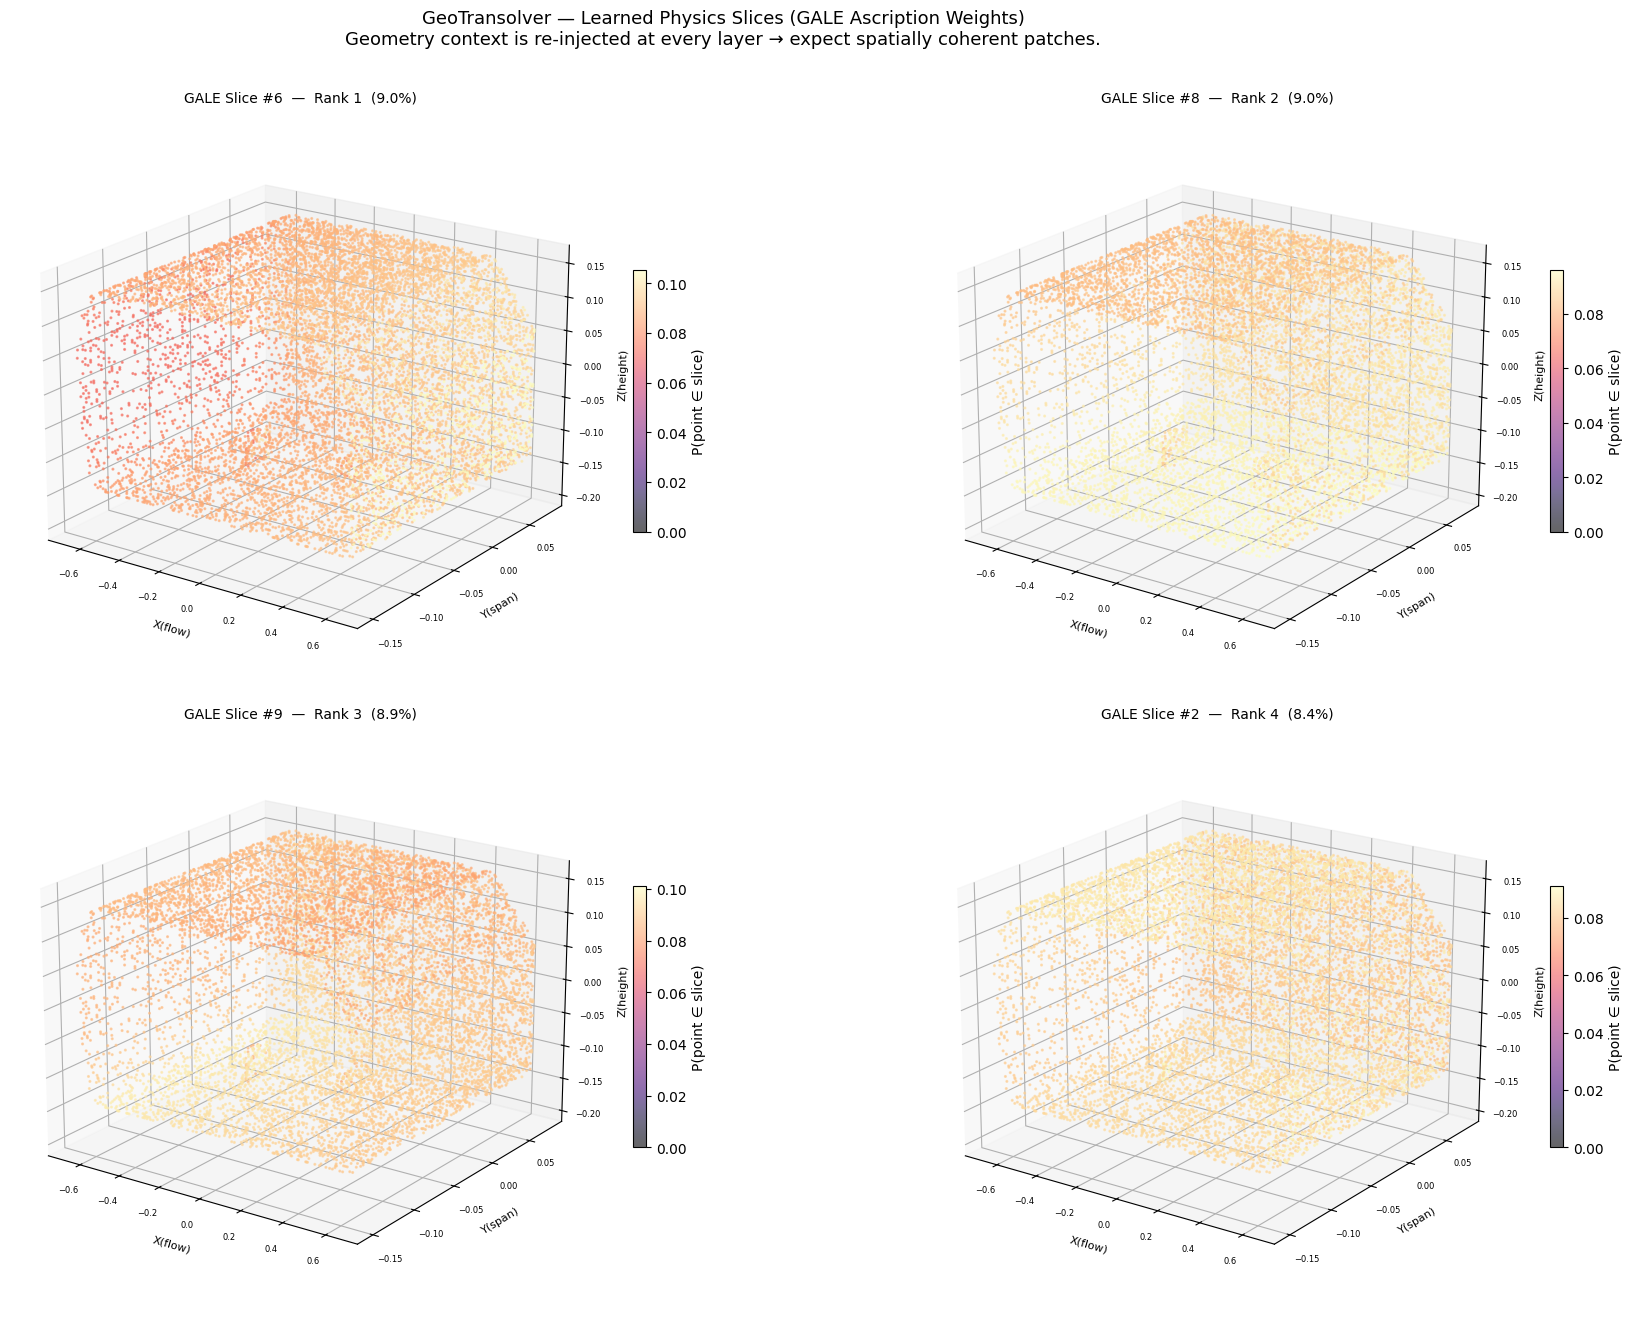

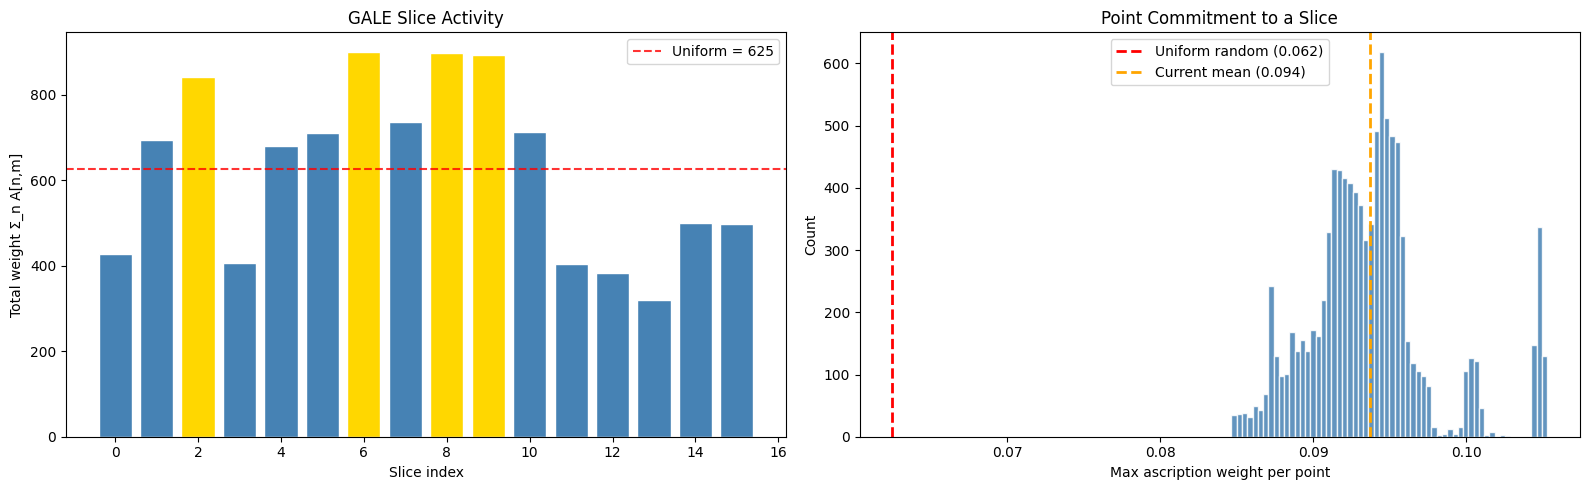

In [12]:
# ── GALE Ascription Weight Visualisation ──────────────────────────────────
geo_model.eval()

# ── Step 1: Get a preprocessed validation sample ──────────────────────────────
# val_datapipe already handles centering, normalisation, and geometry assembly.
sample    = val_datapipe[0]
embeddings = sample["embeddings"].to(device)   # (1, N, 6)  local geometry
geometry   = sample["geometry"].to(device)     # (1, M, 3)  GALE geometry
coords_np  = embeddings[0, :, :3].cpu().numpy()  # (N, 3) for plotting

with torch.no_grad():
    # ── Step 2: Embed local_embedding through preprocess MLP ──────────────────
    # For GeoTransolver, preprocess[0] maps (1,N,functional_dim) → (1,N,n_hidden)
    x_hidden = geo_model.preprocess[0](embeddings)   # (1, N, C_MODEL)

    # ── Step 3: Access the GALE attention module ───────────────────────────────
    # GALE_block stores its attention as 'Attn' (same convention as Transolver)
    gale_attn = geo_model.blocks[0].Attn

    # ── Step 4: Project hidden state onto slice logits ─────────────────────────
    x_mid, fx_mid = gale_attn.project_input_onto_slices(x_hidden)
    slice_projections = gale_attn.in_project_slice(x_mid)   # (1, N, H, S)

    # ── Step 5: Compute ascription weights ────────────────────────────────────
    slice_weights, _ = gale_attn._compute_slices_from_projections(
        slice_projections, fx_mid
    )
    # Average over attention heads → (N, S)
    ascription = slice_weights.mean(dim=2).squeeze(0).cpu().numpy()

print(f"Ascription matrix shape: {ascription.shape}  ({ascription.shape[0]:,} points × {ascription.shape[1]} slices)")
print(f"Row-sum check (should be 1.0): {ascription[0].sum():.6f}")

# ── Step 6: Identify the top-4 most active slices ─────────────────────────────
slice_usage   = ascription.sum(axis=0)
uniform_usage = ascription.shape[0] / M_SLICES
top_k         = 4
top_slices    = np.argsort(slice_usage)[-top_k:][::-1]

print(f"\nTop {top_k} slices (uniform baseline = {uniform_usage:.0f} pts/slice):")
for rank, m in enumerate(top_slices):
    pct = 100 * slice_usage[m] / slice_usage.sum()
    print(f"  Rank {rank+1}: Slice #{m:2d}  {pct:.1f}% of total weight")

# ── Step 7: 3D scatter plot of top 4 slices ───────────────────────────────────
fig = plt.figure(figsize=(20, 13))
fig.suptitle(
    "GeoTransolver — Learned Physics Slices (GALE Ascription Weights)\n"
    "Geometry context is re-injected at every layer → expect spatially coherent patches.",
    fontsize=13, y=1.01
)
for rank, m in enumerate(top_slices):
    ax = fig.add_subplot(2, 2, rank + 1, projection='3d')
    w  = ascription[:, m]
    sc = ax.scatter(coords_np[:, 0], coords_np[:, 1], coords_np[:, 2],
                    c=w, cmap='magma', s=1.5, alpha=0.6, vmin=0, vmax=w.max())
    fig.colorbar(sc, ax=ax, shrink=0.45, pad=0.04, label="P(point ∈ slice)")
    pct = 100 * slice_usage[m] / slice_usage.sum()
    ax.set_title(f"GALE Slice #{m}  —  Rank {rank+1}  ({pct:.1f}%)", fontsize=10)
    for lbl, fn in zip(["X(flow)","Y(span)","Z(height)"],
                       [ax.set_xlabel, ax.set_ylabel, ax.set_zlabel]):
        fn(lbl, fontsize=8)
    ax.view_init(elev=20, azim=-55)
    ax.tick_params(labelsize=6)

plt.tight_layout()
plt.savefig("gale_ascription_weights.png", dpi=100, bbox_inches='tight')
plt.show()

# ── Step 8: Point-commitment histogram ────────────────────────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
colors = ['gold' if i in top_slices else 'steelblue' for i in range(M_SLICES)]
ax.bar(range(M_SLICES), slice_usage, color=colors, edgecolor='white')
ax.axhline(uniform_usage, color='red', ls='--', lw=1.5, alpha=0.8,
           label=f'Uniform = {uniform_usage:.0f}')
ax.set_xlabel("Slice index"); ax.set_ylabel("Total weight Σ_n A[n,m]")
ax.set_title("GALE Slice Activity"); ax.legend()

ax = axes[1]
max_w = ascription.max(axis=1)
ax.hist(max_w, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(1/M_SLICES, color='red', ls='--', lw=2,
           label=f'Uniform random ({1/M_SLICES:.3f})')
ax.axvline(max_w.mean(), color='orange', ls='--', lw=2,
           label=f'Current mean ({max_w.mean():.3f})')
ax.set_xlabel("Max ascription weight per point"); ax.set_ylabel("Count")
ax.set_title("Point Commitment to a Slice"); ax.legend()
plt.tight_layout()
plt.savefig("gale_slice_distribution.png", dpi=100, bbox_inches='tight')
plt.show()

### Figure Interpretation

Each sub-plot colours the Ahmed Body surface by how strongly the model assigns each point to a particular **learned physical slice**. After only a few training epochs:

- **High-entropy, diffuse patterns** (points evenly spread across all slices) indicate the model is still in its early "exploration" phase.
- **Low-entropy, focused patterns** (sharp regions of high weight) indicate the model has learned to associate specific geometric regions with distinct physical phenomena — this is GALE working correctly.

The key difference from Notebook 3's visualisation: the geometry context is **re-injected at every layer**, so even at epoch 5 the slice boundaries should be more geometrically coherent than a vanilla Transolver of the same training length.


Shannon Entropy Analysis
  Mean entropy   : 3.9236 bits  (max possible: 4.00)
  Model certainty: 1.91%

  → High-entropy state: model still converging.
     Increase NUM_EPOCHS for sharper slice boundaries.


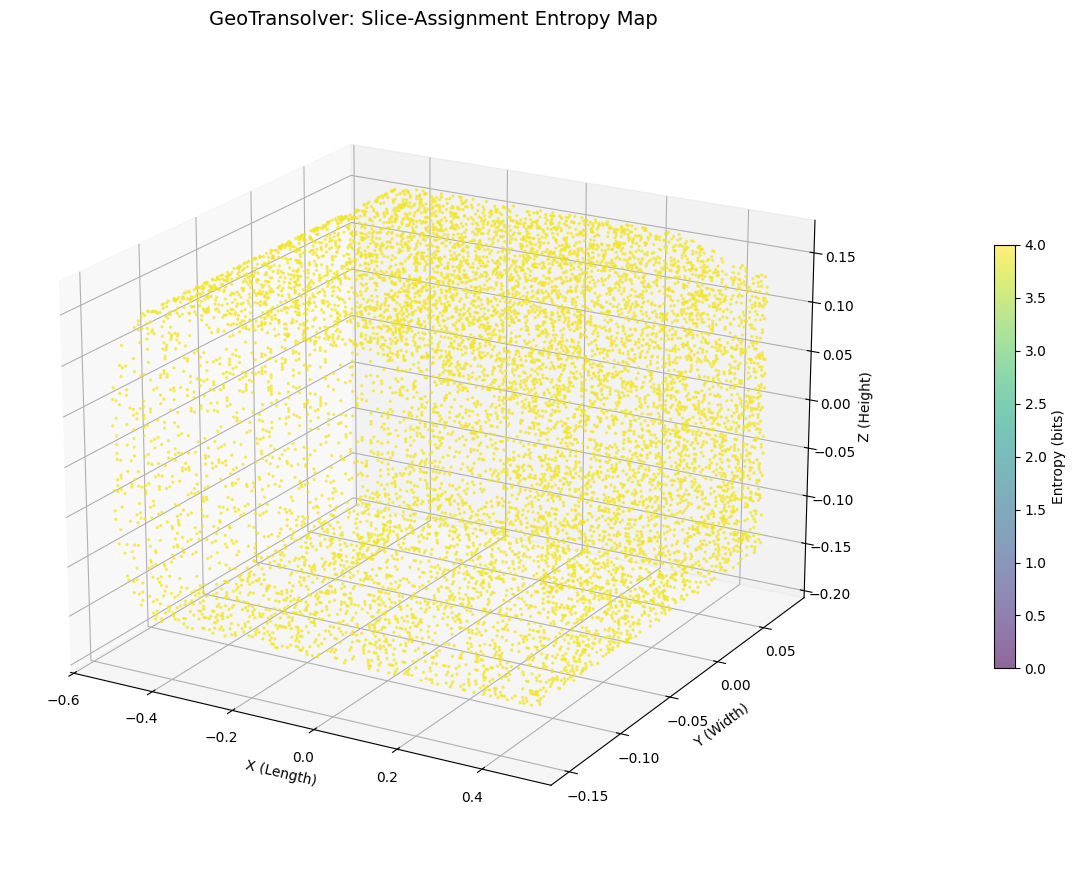

In [14]:
# ── Shannon Entropy Analysis ──────────────────────────────────────────────
eps = 1e-9

# ascription should be shape (N, M_SLICES)
# entropy will be shape (N,)
entropy = -np.sum(ascription * np.log2(ascription + eps), axis=1)

max_ent   = np.log2(M_SLICES)
mean_ent  = np.mean(entropy)
certainty = (1.0 - mean_ent / max_ent) * 100.0

print(f"Shannon Entropy Analysis")
print(f"  Mean entropy   : {mean_ent:.4f} bits  (max possible: {max_ent:.2f})")
print(f"  Model certainty: {certainty:.2f}%")

if certainty < 5.0:
    print("\n  → High-entropy state: model still converging.")
    print("     Increase NUM_EPOCHS for sharper slice boundaries.")
else:
    print("\n  → Model is committing to distinct physical states.")


# ── Get coordinates for entropy map ───────────────────────────────────────
# Use the same batch/case that produced `ascription`.
# embeddings has shape (1, N, 6), where first 3 channels are xyz.
coords = batch["embeddings"][0, :, :3].detach().cpu().numpy()

# Safety checks
if coords.shape[0] != entropy.shape[0]:
    raise ValueError(
        f"coords and entropy have different point counts: "
        f"coords={coords.shape[0]}, entropy={entropy.shape[0]}. "
        f"Make sure `batch` is the same sample used to compute `ascription`."
    )


# ── 3-D entropy map ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    coords[:, 0],
    coords[:, 1],
    coords[:, 2],
    c=entropy,
    cmap="viridis",
    s=2,
    alpha=0.6,
    vmin=0,
    vmax=max_ent,
)

ax.set_title("GeoTransolver: Slice-Assignment Entropy Map", fontsize=14)
ax.set_xlabel("X (Length)")
ax.set_ylabel("Y (Width)")
ax.set_zlabel("Z (Height)")

cbar = fig.colorbar(sc, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label("Entropy (bits)")

ax.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.show()

---
## 9. Summary

Congratulations on completing the full five-notebook series!

### What we built

| Notebook | Takeaway |
|---|---|
| NB1 | Quadratic complexity $O(N^2)$ makes vanilla Transformers impractical for large meshes |
| NB2 | Physics-Attention reduces this to $O(N)$ by routing through $M \ll N$ physics slices |
| NB3 | `TransolverDataPipe` + Transolver trained end-to-end; `broadcast_global_features=True` |
| NB4 | GALE injects geometry context at every layer, preventing representation drift |
| NB5 | Same pipeline, `broadcast_global_features=False`, `include_geometry=True` → GeoTransolver |

### Shared pipeline — what changed between NB3 and NB5

```
TransolverDataPipe config:

  NB3 (Transolver)                       NB5 (GeoTransolver)
  broadcast_global_features = True       broadcast_global_features = False
  include_geometry = False               include_geometry = True

Resulting batch:

  batch["fx"]         (1, N, 2)          batch["fx"]         (1, 1, 2)
  batch["embeddings"] (1, N, 6)          batch["embeddings"] (1, N, 6)
  batch["fields"]     (1, N, 4)          batch["fields"]     (1, N, 4)
                                         batch["geometry"]   (1, M, 3)  ← new

Forward call:

  model(fx=…, embedding=…)               model(global_embedding=…,
                                               local_embedding=…,
                                               geometry=…,
                                               local_positions=…)
```

### Production vs. notebook

In production, model selection happens via Hydra YAML:
```
conf/model/transolver.yaml    → Transolver   (functional_dim: 2)
conf/model/geotransolver.yaml → GeoTransolver (functional_dim: 6, global_dim: 2, geometry_dim: 3)
```
The notebook uses the same class constructors directly with smaller dimensions for speed.

### Next steps
- Increase `NUM_POINTS`, `C_MODEL`, and `NUM_EPOCHS` toward production values.
- Enable `scale_invariance=True` (reference_scale from `core.yaml`) for car-size robustness.
- Run inference on a new geometry and compare Transolver vs. GeoTransolver predictions.